In [4]:
import numpy as np
import trimesh

# Load the GLB file
mesh = trimesh.load(r"C:\Users\victo\OneDrive - BGU\Nina\stones.glb")

# Calculate the surface area
surface_area = mesh.area
print(f'Surface Area: {surface_area}')


# Check if the mesh is valid
if not mesh.is_empty:
    # Show the mesh in a viewer
    mesh.show()
else:
    print("The mesh is empty or invalid.")




Surface Area: 2.6079458488433236


In [1]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean, circstd
import os
import sys
import pandas as pd
pd.options.mode.chained_assignment = None
import seaborn as sns
import sys,time,random
import matplotlib

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

In [13]:
df.FRAME.min(), df.FRAME.max()

(0, 69)

In [14]:
df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\HBEC\s2(120-919)\Tracking\spots_100_600_scale05.csv", skiprows=[1,2,3])


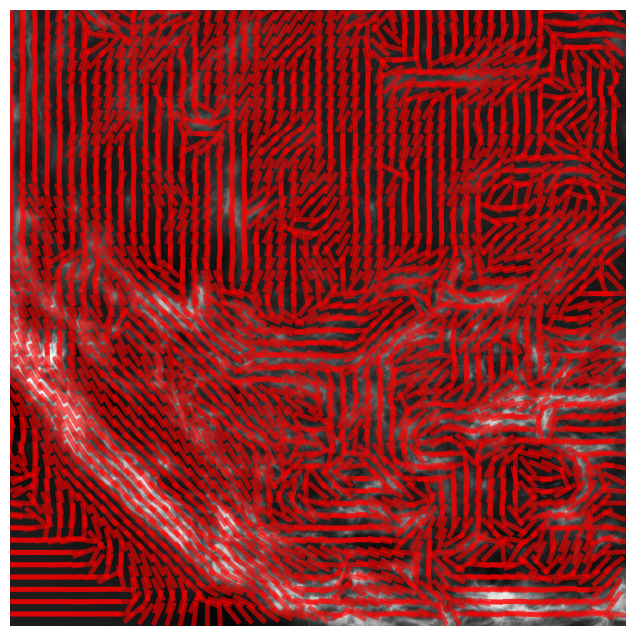

In [4]:
%matplotlib inline
im_num = 100
fig, ax1 = plt.subplots(1,1,  figsize=(8,8))

ax1.clear(); ax1.axis('off') 

im = r"C:\Users\victo\Downloads\reorientationorderanalysis\t12z6_1.tif"

img1 = cv2.imread(im)[:1000,:1000,0]

y, x = np.mgrid[0:img1.shape[0], 0:img1.shape[1]]

sigma = 15
ori, plus, min = analyze_defects(img1, sigma=sigma)

s = 20
# ax1.imshow(np.zeros_like(img1, dtype=np.float32), cmap="gray")
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img1)
ax1.imshow(img_clahe, cmap="gray")  

ax1.quiver(x[::s,::s], y[::s,::s],
    np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], 
    headaxislength=0, headwidth=0, headlength=0, width=.008, 
    color="r", scale=25, pivot='mid', alpha=.6)
    
plt.gca().set_box_aspect(1)

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import skimage.measure
from scipy.stats import entropy
from scipy.ndimage import sobel
from scipy.ndimage import rotate, gaussian_filter

def count_frames(tiff):
    # Initialize a counter for the frames
    frame_count = 0
    # Loop through all frames in the TIFF file
    while True:
        try:
            tiff.seek(frame_count)
            frame_count += 1
        except EOFError:
            break
    return frame_count

def multiTiff_entropy(tiff, norm=False):
    entropy_ = []
    # Initialize a counter for the frames
    frame_count = 0
    # Loop through all frames in the TIFF file
    while True:
        try:
            tiff.seek(frame_count)
            entropy_.append(skimage.measure.shannon_entropy(tiff.copy()))
            frame_count += 1
        except EOFError:
            break
    
    # return [e/entropy_[0]/(np.max(entropy_)-np.min(entropy_)) for e in entropy_]
    if norm:
        return [e/np.max(entropy_) for e in entropy_]
    else:
        return entropy_
    
def calculate_sharpness(tiff, sigma=5, norm=False):
    sharpness = []
    # Initialize a counter for the frames
    frame_count = 0
    # Loop through all frames in the TIFF file
    while True:
        try:
            tiff.seek(frame_count)
            image_np = np.array(tiff.copy())
            # Apply the Sobel filter to find the gradient magnitude
            dx = gaussian_filter(sobel(image_np, axis=0), sigma=sigma) # Gradient in x direction
            dy = gaussian_filter(sobel(image_np, axis=1), sigma=sigma)  # Gradient in y direction
            gradient_magnitude = np.hypot(dx, dy)  # Magnitude of the gradient
            sharpness.append(np.mean(gradient_magnitude))
            frame_count += 1
        except EOFError:
            break

    if norm:
        return [e/np.max(sharpness) for e in sharpness]
    else:
        return sharpness


    # Open the image
    image = Image.open(image_path)
    # Convert the image to grayscale
    image = image.convert('L')
    # Convert the image to a numpy array
    image_np = np.array(image)
    # Apply the Sobel filter to find the gradient magnitude
    dx = sobel(image_np, axis=0)  # Gradient in x direction
    dy = sobel(image_np, axis=1)  # Gradient in y direction
    gradient_magnitude = np.hypot(dx, dy)  # Magnitude of the gradient
    # Calculate the mean gradient magnitude as the acutance
    acutance = np.mean(gradient_magnitude)
    return sharpness    


def multiTiff_to_list(tiff):
    img_list = []
    # Initialize a counter for the frames
    frame_count = 0
    # Loop through all frames in the TIFF file
    while True:
        try:
            tiff.seek(frame_count)
            img_list.append(np.array(tiff.copy()))
            frame_count += 1
        except EOFError:
            break
    return img_list


# Open the multi-page TIFF file
tiff_path = r"E:\Quris\Opera\Akura96\10x\Quris 2nd PoC Akura96 10x FL Stack__2024-05-08T11_28_12-Measurement 1\crops\Images-1.tif"
tiff = Image.open(tiff_path)

# Frame number to display (adjust this number as needed)
frame_number = 0

# Get the frame
# frame = get_frame(tiff, frame_number)
tiff.seek(frame_number)
frame = tiff.copy()

# Convert the frame to a numpy array for display
frame_np = np.array(frame)

# Display the frame using matplotlib
plt.imshow(frame_np, cmap='gray')  # Use 'gray' colormap for grayscale images
plt.title("frame %s from %s" %(frame_number, count_frames(tiff)))
# plt.axis('off')  # Hide axes

FileNotFoundError: [Errno 2] No such file or directory: 'E:\\Quris\\Opera\\Akura96\\10x\\Quris 2nd PoC Akura96 10x FL Stack__2024-05-08T11_28_12-Measurement 1\\crops\\Images-1.tif'

In [42]:
%matplotlib qt
tif_list = glob.glob(r"E:\Quris\Opera\Akura96\10x\Quris 2nd PoC Akura96 10x FL Stack__2024-05-08T11_28_12-Measurement 1\crops\*")
hrange = [1.2e4, 3.e4]
# tif_list = glob.glob(r"E:\Quris\CD7\Akura96\crops\*")
# hrange = [1.4e2, 1.5e4]
# tif_list = glob.glob(r"E:\Quris\Thorlabs\Akura96\10x\crops\*")
# hrange = [0, 255]

bin_num = 300
bins = np.linspace(hrange[0],hrange[1], bin_num+1)
bins_ = np.linspace(hrange[0],hrange[1], bin_num)

fig, axs = plt.subplots(2,2, figsize=(12,12))

for ax1, tiff_path in zip(axs.ravel(), tif_list):
    tiff = Image.open(tiff_path)
    ax1.set_box_aspect(1)
    colors = plt.cm.jet(np.linspace(0,1,count_frames(tiff)))

    
    for (i,im), color in zip(enumerate(multiTiff_to_list(tiff)), colors):
        p1,_,_ = ax1.hist(im.ravel(), bins, density=True, alpha=0)
        ax1.plot(bins_, p1, color=color, linewidth=3, alpha=.6, label=i)
    
    ax1.legend(loc='upper right', fontsize=14) 
    ax1.set_title(os.path.basename(tiff_path))   

In [7]:
calculate_sharpness(tiff)

[203.1, 203.6, 204.1, 204.4, 203.6, 205.8, 207.1, 207.0, 205.8, 205.4]

Text(0.5, 0, '$Frame$')

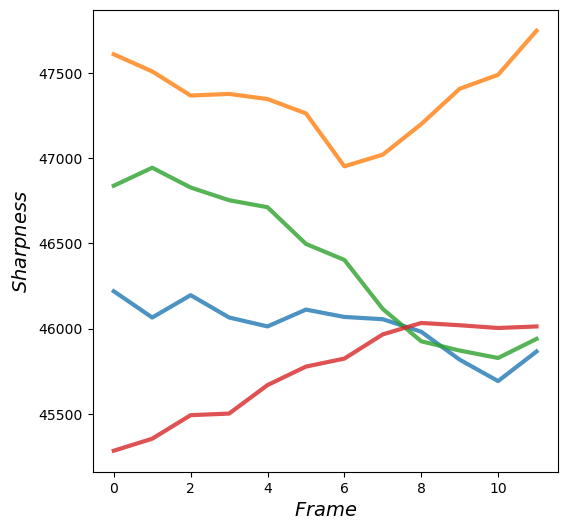

In [37]:
%matplotlib inline
tif_list = glob.glob(r"E:\Quris\Opera\Akura96\10x\Quris 2nd PoC Akura96 10x FL Stack__2024-05-08T11_28_12-Measurement 1\crops\*")
# tif_list = glob.glob(r"E:\Quris\Thorlabs\Akura96\10x\crops\*")
# tif_list = glob.glob(r"E:\Quris\CD7\Akura96\crops\*")

fig, axs = plt.subplots(1,1, figsize=(6,6))
for path in tif_list[:]:
    tiff = Image.open(path)
    # info = multiTiff_entropy(tiff)
    info = calculate_sharpness(tiff, sigma=45, norm=False)
    plt.plot(np.arange(len(info)), info, "-", linewidth=3, alpha=.8, label=os.path.basename(path).split(".")[0])

# plt.legend(loc='lower right', fontsize=14)
# plt.ylabel(r"$Shannon ~Entropy$", fontsize=14)
plt.ylabel(r"$Sharpness$", fontsize=14)
plt.xlabel(r"$Frame$", fontsize=14)
# plt.ylim([6.7, 7.3])
# plt.xlim([0, 9])

# Odd Viscosity

In [1]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean
import os
import sys, time,random
from pathlib import Path
from PIL import Image
from joblib import Parallel, delayed
import h5py
import pickle 

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

In [ ]:
# image_list = glob.glob(r"C:\Users\victo\My Drive\Curie\DESKTOP\HT1080\400\89_3\*.tif")
# image_list = natsorted(image_list, key=lambda y: y.lower())

# u = np.zeros_like(cv2.imread(image_list[0])[:,:,0], dtype=np.float32)
# v = np.zeros_like(u)

# for (i,img1),img2 in zip(enumerate(image_list[:-1]), image_list[1:]):
#     im1 = cv2.imread(img1)[...,0]
#     im2 = cv2.imread(img2)[...,0]
#     flow = cv2.calcOpticalFlowFarneback(im1,im2, None, 0.5, 3, 
#         winsize=15, iterations=3, poly_n=5, poly_sigma=1.2, flags=0) 
#     flow[:,:,0] = gaussian_filter(flow[:,:,0], sigma=15)
#     flow[:,:,1] = gaussian_filter(flow[:,:,1], sigma=15)
#     u += flow[..., 0]
#     v += flow[..., 1]

#     if i>30:
#         break

In [ ]:
# %matplotlib qt
# step = 25
# sigma = 15

# fig, ax1 = plt.subplots(1,1)

# clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
# img_clahe = clahe.apply(im1)
# ax1.imshow(255-img_clahe, cmap="gray")  

# field = np.stack((flow[:,:,0], flow[:,:,1]), axis=-1)
# # flow[:,:,0] = gaussian_filter(flow[:,:,0], sigma=sigma)
# # flow[:,:,1] = gaussian_filter(flow[:,:,1], sigma=sigma)
# # gaussian_filter
# vorticity = gaussian_filter(curl_npgrad(field), sigma=sigma)
# # c = ax1.imshow(vorticity, cmap='RdBu', alpha=.3)
# # fig.colorbar(c, ax=ax1)

# vort_min = 0.005
# vortTFr = vorticity > vort_min
# vortTFl = vorticity < vort_min
# ur = flow[:,:,0] * vortTFr
# vr = flow[:,:,1] * vortTFr
# ul = flow[:,:,0] * vortTFl
# vl = flow[:,:,1] * vortTFl

# ax1.quiver(x[::step, ::step], y[::step, ::step], 
#         ur[::step, ::step], -vr[::step, ::step], 
#         color="b", scale=50, alpha=.8, width=.002, minlength=0)
# ax1.quiver(x[::step, ::step], y[::step, ::step], 
#         ul[::step, ::step], -vl[::step, ::step], 
#         color="r", scale=50, alpha=.8, width=.002, minlength=0)    

# # y, x = np.mgrid[0:im1.shape[0], 0:im1.shape[1]]
# # ax1.quiver(x[::step, ::step], y[::step, ::step], 
# #         flow[::step, ::step, 0], -flow[::step, ::step, 1], 
# #         color="red", scale=50, alpha=.9, width=.005)

## Create list of stripes in range <>

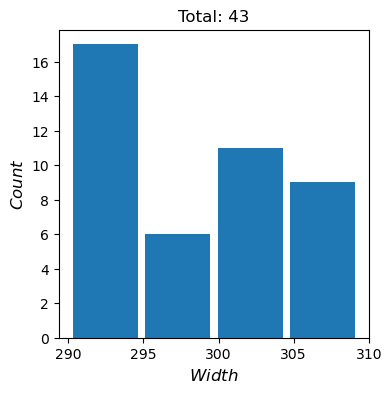

In [2]:
%matplotlib inline
# Example usage
# fig, ax = plt.subplots(1,1,  figsize=(4,4))
width = 300
tiff_list = analyze_image_widths(r"C:\Users\victo\Downloads\HT1080", width, dw=width//30, make_plot=True)#, ax=ax)

In [4]:
# calculate average flow for each stripe  
uv_list = Parallel(n_jobs=5)(delayed(uv_time_average)(tiff_path) for tiff_path in tiff_list[:])
# remove None
uv_list1 = [uv for uv,ti in zip(uv_list, tiff_list) if uv is not None]
tiff_list1 = [ti for uv,ti in zip(uv_list, tiff_list) if uv is not None]
print(len(tiff_list1), " from ", len(tiff_list))

35  from  43


C:\Users\victo\AppData\Local\Temp\ipykernel_19600\1042805385.py:22: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  for c,uv in zip(colors, np.array(uv_list1)[idx]):


Text(0.5, 1.0, '$Sorted$')

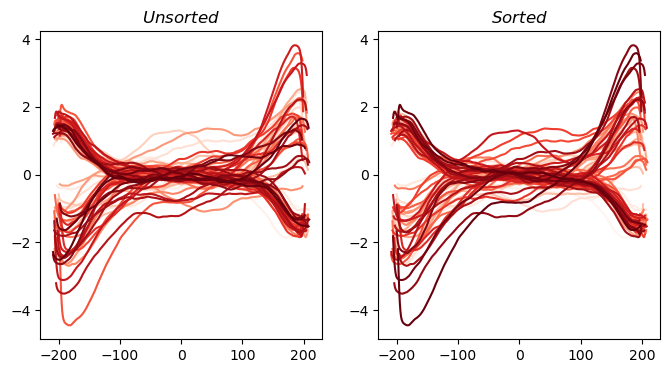

In [6]:
# sort by shear amplitude

def shear_amplitude_order(uv_list, boundary=20):
    '''uv_list sotred by shear (v_y) amplitude on the edges'''
    shear_amplitude = [(uv[:,-boundary:,1].mean() - uv[:,:boundary,1].mean()) for uv in uv_list]
    return np.argsort(shear_amplitude)

import matplotlib.cm as cm
colors = cm.Reds(np.linspace(0, 1, len(uv_list1)))

fig, axs = plt.subplots(1,2, figsize=(8,4))

for c,uv in zip(colors,uv_list1):
    u_profile = uv[:,:,0].mean(axis=0)
    v_profile = uv[:,:,1].mean(axis=0)
    width = np.linspace(-len(u_profile) // 2, len(u_profile) // 2, len(u_profile))
    axs[0].plot(width, v_profile, color=c)
    axs[0].plot(width, u_profile, color=c)
axs[0].set_title("$Unsorted$")

idx = shear_amplitude_order(uv_list1) 
for c,uv in zip(colors, np.array(uv_list1)[idx]):
    u_profile = uv[:,:,0].mean(axis=0)
    v_profile = uv[:,:,1].mean(axis=0)
    width = np.linspace(-len(u_profile) // 2, len(u_profile) // 2, len(u_profile))
    axs[1].plot(width, v_profile, color=c)
    axs[1].plot(width, u_profile, color=c)
axs[1].set_title("$Sorted$")    

In [ ]:
# Show profiles or profile ratio 
# Sorted by shear amplitude


# fig, axs = plt.subplots(3,6)
%matplotlib qt
fig1, axs = plt.subplots(3,len(tiff_list1)//3 + 1)
axs = axs.ravel()
count = 0

idx = shear_amplitude_order(uv_list1) 

for (i,uv),tiff_path  in zip(enumerate(np.array(uv_list1)[idx[::-1]]), np.array(tiff_list1)[idx[::-1]]):
    uprofile = uv[:,:,0].mean(axis=0)
    vprofile = uv[:,:,1].mean(axis=0)
    if (vprofile[-10:].mean() - vprofile[:10].mean())> 1.:
        # axs[count].plot(np.arange(len(uprofile)), uprofile, "r", label="$v_x$")
        # axs[count].plot(np.arange(len(vprofile)), vprofile,"b", label="$v_y$")
        # axs[count].legend(loc='upper left', fontsize=12)
        # axs[count].set_ylim([-3,3])

        axs[count].plot(uprofile, vprofile-vprofile.mean(axis=0),"or", alpha=.1)
        axs[count].set_box_aspect(1); axs[count].plot([-1,1], [1,-1],"--k", alpha=.6)
        axs[count].set_xlim([-3,3]); axs[count].set_ylim([-3,3])

        axs[count].set_title(os.path.basename(tiff_path))

        count+=1

C:\Users\victo\AppData\Local\Temp\ipykernel_19600\2568391145.py:13: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  for (i,uv),tiff_path  in zip(enumerate(np.array(uv_list1)[idx[::-1]]), np.array(tiff_list1)[idx[::-1]]):


In [9]:
np.array(tiff_list1)[idx[::-1]][:5]

array(['C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s53_2.tif',
       'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s65_3.tif',
       'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s65_2.tif',
       'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s66_3.tif',
       'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s62_4.tif'],
      dtype='<U59')

In [214]:
import h5py

# save uv
def uv_save_from_multitiff(tiff_path, save_dir):
    tiff = Image.open(tiff_path)
    tiff_frame_list = multiTiff_to_list(tiff)

    exp_num = os.path.basename(tiff_path).split(".")[-2]
    save_path  = save_dir + exp_num + "/Flow"
    os.makedirs(save_path, exist_ok=True)

    for (i,img1),img2 in zip(enumerate(tiff_frame_list[:-1]), tiff_frame_list[1:]):
        flow = cv2.calcOpticalFlowFarneback(img1,img2, None, 0.5, 3, 
            winsize=15, iterations=3, poly_n=5, poly_sigma=1.2, flags=0) 
        
        with h5py.File(save_path +"/flow_"+ str(i), 'w') as f:
            f.create_dataset('flow', data=flow.astype(np.float16))
    
    return 

# exp_num = os.path.basename(tiff_list1[2]).split(".")[-2]
# save_dir  = r"C:\Users\victo\Downloads\HT1080\Odd_test\w300/"

# # for tiff_path in tiff_list1[:1]:
# #     uv_save_from_multitiff(tiff_path, save_dir)

# Parallel(n_jobs=15)(delayed(uv_save_from_multitiff)(tiff_path, save_dir) for tiff_path in tiff_list1[:])


In [ ]:
wws = [300, 400, 500, 600, 800, 1000]

def shear_amplitude_order(uv_list, boundary=20):
    '''uv_list sotred by shear (v_y) amplitude on the edges'''
    shear_amplitude = [(uv[:,-boundary:,1].mean() - uv[:,:boundary,1].mean()) for uv in uv_list]
    return np.argsort(shear_amplitude)

for width in wws:
    tiff_list = analyze_image_widths(r"C:\Users\victo\Downloads\HT1080", width, dw=width//30, make_plot=False)#, ax=ax)
    uv_list = Parallel(n_jobs=5)(delayed(uv_time_average)(tiff_path) for tiff_path in tiff_list[:])
    # remove None
    uv_list1 = [uv for uv,ti in zip(uv_list, tiff_list) if uv is not None]
    tiff_list1 = [ti for uv,ti in zip(uv_list, tiff_list) if uv is not None]
    print(len(tiff_list1), " from ", len(tiff_list))

    idx = shear_amplitude_order(uv_list1) 

    save_dir = r"C:\Users\victo\Downloads\HT1080\Odd_test/w"+str(width)+ "/"
    os.makedirs(save_path, exist_ok=True)

    Parallel(n_jobs=15)(delayed(uv_save_from_multitiff)(tiff_path, save_dir) for tiff_path in np.array(tiff_list1)[idx[::-1]][:3])
            # if i>3:
            #     break

In [14]:
%matplotlib qt

fig, axs = plt.subplots(3,len(tiff_list1)//3 + 1)
# fig, axs = plt.subplots(3,6)
axs = axs.ravel()
count = 0

idx = shear_amplitude_order(uv_list1) 

for (i,uv),tiff_path  in zip(enumerate(np.array(uv_list1)[idx[::-1]]), np.array(tiff_list1)[idx[::-1]]):
    vprofile = uv[:,:,1].mean(axis=0)

    if (vprofile[-10:].mean() - vprofile[:10].mean())> 1.5:
        max_abs = np.max(np.abs(uv[:,:,1]))
        axs[count].imshow(uv[:,:,1], "seismic", vmin=-max_abs, vmax=max_abs)
        axs[count].set_title(os.path.basename(tiff_path))
        count+=1

C:\Users\victo\AppData\Local\Temp\ipykernel_5412\1944528285.py:10: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  for (i,uv),tiff_path  in zip(enumerate(np.array(uv_list1)[idx[::-1]]), np.array(tiff_list1)[idx[::-1]]):


## Save Flow fields

In [ ]:
def uv_save(tiff_frame_list, save_path):
    os.makedirs(save_path, exist_ok=True)

    for (i,img1),img2 in zip(enumerate(tiff_frame_list[:-1]), tiff_frame_list[1:]):
        flow = cv2.calcOpticalFlowFarneback(img1,img2, None, 0.5, 3, 
            winsize=15, iterations=3, poly_n=5, poly_sigma=1.2, flags=0) 

        with h5py.File(save_path +"/flow_"+ str(i), 'w') as f:
            f.create_dataset('flow', data=flow.astype(np.float16))

exp_num = "s63"
tiff_path_list = glob.glob(r"C:\Users\victo\Downloads\HT1080\Odd_test/"+exp_num+"/Raw\*")
tiff_list = [cv2.imread(path)[...,0] for path in tiff_path_list]

save_path  = r"C:\Users\victo\Downloads\HT1080\Odd_test/"+exp_num+"/Flow"
os.makedirs(save_path, exist_ok=True)
uv_save(tiff_list, save_path)

In [60]:
# read tiff
tiff = Image.open(tiff_path)
# multitiff to list
tiff_frame_list = multiTiff_to_list(tiff)

tiff_path

'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s92_1.tif'

In [ ]:
# # read tiff
# tiff = Image.open(tiff_path)
# # multitiff to list
# tiff_frame_list = multiTiff_to_list(tiff)

# for (i,img1),img2 in zip(enumerate(tiff_frame_list[:-1]), tiff_frame_list[1:]):
#     flow = cv2.calcOpticalFlowFarneback(img1,img2, None, 0.5, 3, 
#         winsize=15, iterations=3, poly_n=5, poly_sigma=1.2, flags=0) 

#     with h5py.File(save_flow_path, 'w') as f:
#         f.create_dataset('flow', data=flow.astype(np.float16))


In [ ]:
# import h5py

# with h5py.File(r'C:\Users\victo\Downloads\HT1080\Odd_test\flow_001.h5', 'w') as f:
#     f.create_dataset('flow', data=uv)

In [ ]:
# # Open the HDF5 file
# with h5py.File(r'C:\Users\victo\Downloads\HT1080\Odd_test\s55\Flow\flow_0', 'r') as f:
#     # Get the dataset (matrix) from the file
#     flow = f['flow'][:]

# print('Length: %s \mum, Width: %s \mum' % (flow.shape[0]*.74,flow.shape[1]*.74))

# # >> Length: 1485.18 \mum, Width: 807.34 \mum

Length: 1485.18 \mum, Width: 807.34 \mum


304.14


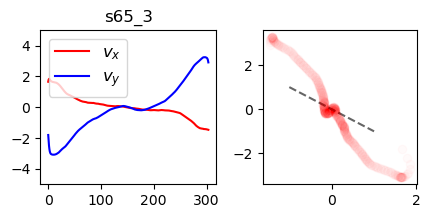

In [12]:
# read and plot optical flow files
%matplotlib inline
# s52, s53, s54, s55, s56, and s63
exp_num = "s65_3"
uv_pathlist = natsorted(glob.glob(r"C:\Users\victo\Downloads\HT1080\Odd_test\*/*"+exp_num+"/Flow\*"))


flow = []
for p in uv_pathlist:
    # Open the HDF5 file
    with h5py.File(p, 'r') as f:
        # Get the dataset (matrix) from the file
        flow.append(f['flow'][:])

uprofile = np.mean([uv[:,:,0].mean(axis=0) for uv in flow], axis=0)
# uprofile = uprofile-uprofile.mean(axis=0)
vprofile = np.mean([uv[:,:,1].mean(axis=0) for uv in flow], axis=0)
# vprofile = vprofile-vprofile.mean(axis=0)
fig, axs = plt.subplots(1,2, figsize=(5,2))
axs[0].plot(np.arange(uprofile.shape[0])*.74, uprofile,"r", label="$v_x$")
axs[0].plot(np.arange(vprofile.shape[0])*.74, vprofile,"b", label="$v_y$")
axs[0].legend(loc='upper left', fontsize=12)
axs[0].set_ylim([-5,5])
axs[0].set_title(os.path.dirname(uv_pathlist[0]).split("\\")[-2])
axs[1].plot([-1,1], [1,-1],"--k", alpha=.6)
axs[1].plot(uprofile, vprofile,"or", alpha=.02)
axs[1].set_box_aspect(1)
print(len(uprofile)*.74)

In [93]:
from skimage.measure import label, regionprops, regionprops_table
def find_centers(masks):
    '''find centers in segmented image b/w or labels'''
    regions = regionprops(masks)
    x_cent = []
    y_cent = []
    label_num = []
    for i,props in enumerate(regions):
        yi, xi = props.centroid
        x_cent.append(xi)
        y_cent.append(yi)
        label_num.append(props.label)
        # plt.text(xi, yi, str(i))
    return x_cent, y_cent, label_num

m_path = r"C:\Users\victo\Downloads\HT1080\Odd_test\s53\Mask2\s530100_cp_masks.png"
masks = cv2.imread(m_path, flags=cv2.IMREAD_ANYDEPTH)
x_cent, y_cent, label_num = find_centers(masks)
x_cent

[6.472566371681416,
 39.6839762611276,
 72.29473684210527,
 107.64771048744461,
 145.66010928961748,
 206.13271028037383,
 223.14583333333334,
 255.56976744186048,
 279.2586206896552,
 298.57297830374756,
 325.0485537190083,
 353.4074585635359,
 396.68840579710144,
 447.53831775700934,
 479.065625,
 494.8228346456693,
 515.7312925170068,
 530.3460837887068,
 558.2152466367713,
 590.5454545454545,
 607.9689440993789,
 619.5614973262032,
 651.7335423197492,
 669.4476987447699,
 696.4876033057851,
 704.5225806451613,
 727.1266163793103,
 754.8423326133909,
 768.8007033997656,
 770.779746835443,
 800.1463414634146,
 831.4410480349345,
 856.469696969697,
 866.9057971014493,
 890.6430401366354,
 917.8538011695906,
 935.1735015772871,
 954.0160142348755,
 977.507326007326,
 999.6797900262467,
 1024.6678921568628,
 1048.6913580246915,
 1066.1816326530611,
 27.507246376811594,
 375.49122807017545,
 372.4632867132867,
 15.284403669724771,
 508.9569377990431,
 807.8019662921348,
 576.573770491803

(array([3469., 2025., 2302., 2198., 2178., 2144., 2137., 2044., 2006.,
        2175., 2076., 2140., 2080., 2087., 2092., 2166., 2176., 2192.,
        2241., 2223., 2184., 2213., 2254., 2297., 2272., 2245., 2253.,
        2317., 2275., 2274., 2325., 2283., 2282., 2275., 2274., 2247.,
        2364., 2332., 2412., 2334., 2297., 2252., 2278., 2297., 2327.,
        2349., 2320., 2376., 2362., 2450., 2582., 2542., 2589., 2646.,
        2681., 2810., 2756., 2641., 2588., 1343.]),
 array([6.45631068e-01, 1.88872418e+01, 3.71288526e+01, 5.53704633e+01,
        7.36120741e+01, 9.18536848e+01, 1.10095296e+02, 1.28336906e+02,
        1.46578517e+02, 1.64820128e+02, 1.83061739e+02, 2.01303349e+02,
        2.19544960e+02, 2.37786571e+02, 2.56028182e+02, 2.74269792e+02,
        2.92511403e+02, 3.10753014e+02, 3.28994625e+02, 3.47236235e+02,
        3.65477846e+02, 3.83719457e+02, 4.01961068e+02, 4.20202678e+02,
        4.38444289e+02, 4.56685900e+02, 4.74927511e+02, 4.93169121e+02,
        5.11410732

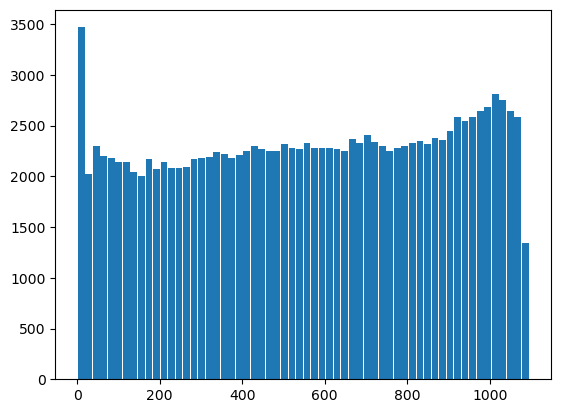

In [89]:
df = pd.read_csv(r"C:\Users\victo\Downloads\HT1080\Odd_test\s52\_allspots.csv", skiprows=[1,2,3])
plt.hist(df.POSITION_X, bins=60, rwidth=.9)

In [124]:
import matplotlib.pyplot as plt
import cv2
from skimage.color import label2rgb
from skimage.measure import label, regionprops
import pathlib
import os

folder = r"C:\Users\victo\Downloads\HT1080\Odd_test\79_2"
raw_path = folder + r"\Raw\s79_20005.tif"
mask_path = os.path.join(
    str(pathlib.Path(raw_path).parents[1]),
    "Mask",
    raw_path.split(os.sep)[-1].split(".")[0]+"_cp_masks.png"
    )

raw = cv2.imread(raw_path, flags=cv2.IMREAD_ANYDEPTH)
masks = cv2.imread(mask_path, flags=cv2.IMREAD_ANYDEPTH)

plt.imshow(raw, cmap="gray", alpha=1.)
plt.imshow(label2rgb(masks, bg_label=0), alpha=0.3)
plt.title(os.path.basename(raw_path))


Text(0.5, 1.0, 's79_20005.tif')

In [140]:
imread(r"C:\Users\victo\Downloads\HT1080\27072018_CROPPED\s53_2.tif")[:,:500,:].shape

100%|██████████| 101/101 [00:00<00:00, 2697.03it/s]


(101, 2028, 396)

100%|██████████| 101/101 [00:00<00:00, 1773.74it/s]


401


Text(0.5, 1.0, '401')

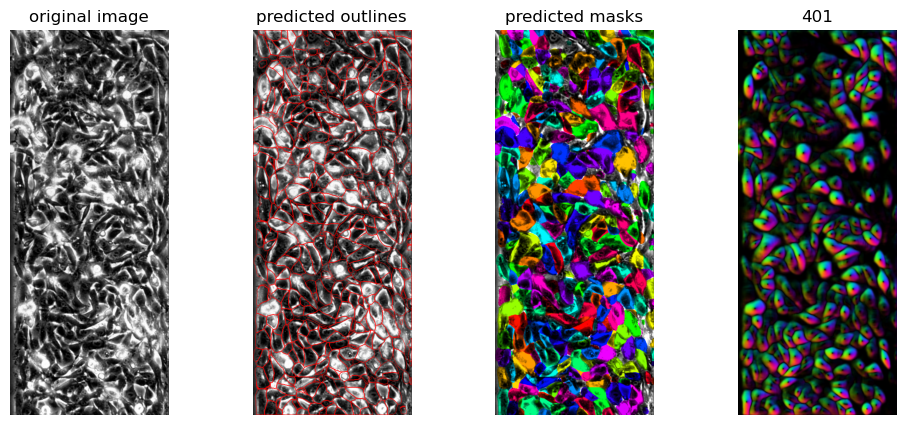

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io, plot
from cellpose.io import imread

%matplotlib inline
model = models.Cellpose(gpu=True, model_type = "cyto3")

# img = cv2.imread(r"C:\Users\victo\Downloads\HT1080\Odd_test\79_2\Raw\s79_20099.tif")[:1000,:,0]
img = imread(r"C:\Users\victo\Downloads\HT1080\27072018_CROPPED\s65_3.tif")[-1,:1000,:]

masks, flows, styles, diams = model.eval(img, diameter=32., channels = [1,3],
                                         flow_threshold=1,
                                         cellprob_threshold=-6,
                                        #  min_size=20.,
                                        #  niter=2000
                                         )# rescale= 27./280.)
print(len(np.unique(masks)))
# DISPLAY RESULTS

# overlay = plot.mask_overlay(img, masks)
# fig,axs = plt.subplots(1,2,figsize=(15,10))
# axs[0].imshow(overlay)
# axs[1].imshow(flows[0])

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img, masks, flows[0], channels=[0,0])
plt.title(len(np.unique(masks)))

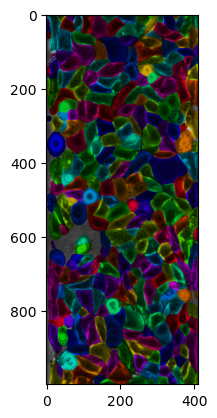

In [133]:
overlay = plot.mask_overlay(img, masks)
plt.imshow(overlay)

In [144]:
imread(r"C:\Users\victo\Downloads\HT1080\27072018_CROPPED\s65_3.tif").shape[0]

100%|██████████| 101/101 [00:00<00:00, 2443.42it/s]


101

In [146]:
imread(r"C:\Users\victo\Downloads\HT1080\27072018_CROPPED\s65_3.tif").shape

100%|██████████| 101/101 [00:00<00:00, 2544.28it/s]


(101, 2037, 411)

100%|██████████| 101/101 [00:00<00:00, 2560.93it/s]


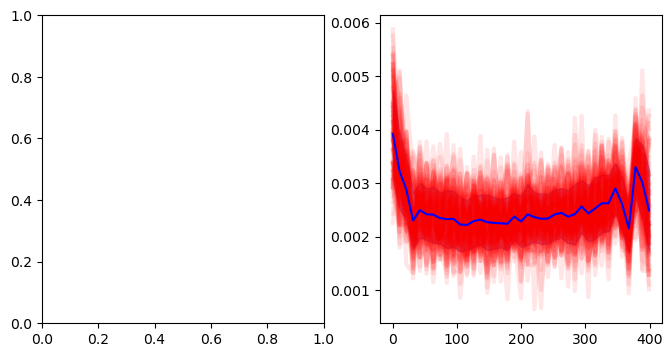

In [169]:
model = models.Cellpose(gpu=True, model_type = "cyto3")

plt.figure(figsize=(8,4))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122)

tiff_path = r"C:\Users\victo\Downloads\HT1080\27072018_CROPPED\s65_2.tif"

frame_num,_ , width  = imread(tiff_path).shape

bins = np.linspace(0, width, width//10+1) #* 180/np.pi
bins_ = np.linspace(0, width, width//10)

profiles = []
for frame in range(frame_num):
    masks,_,_,_ = model.eval(imread(tiff_path)[frame], 
                                         diameter=32., channels = [1,3],
                                         flow_threshold=1,
                                         cellprob_threshold=-6
                                         )

    # p,_,_ = ax1.hist([region.centroid[1] for region in regionprops(masks)], bins, )
    p,_ = np.histogram([region.centroid[1] for region in regionprops(masks)], bins, density=True)
    ax2.plot(bins_, p, "r", linewidth=3, alpha=.1)

    profiles.append(p)



av = np.mean(profiles, axis=0)
std = np.std(profiles, axis=0) 

output_path = r"C:\Users\victo\OneDrive - BGU\DATA\Odd_test\Images"
dict = {'width': bins_*.74, 'density_av': av} 
pd.DataFrame(dict).to_csv(output_path + "/"+ str(int(bins_[-1]*.74)) + "_sort.csv")

ax2.plot(bins_, av, "b")
ax2.fill_between(bins_, av+std, av-std,
                 color="b", alpha=.3)

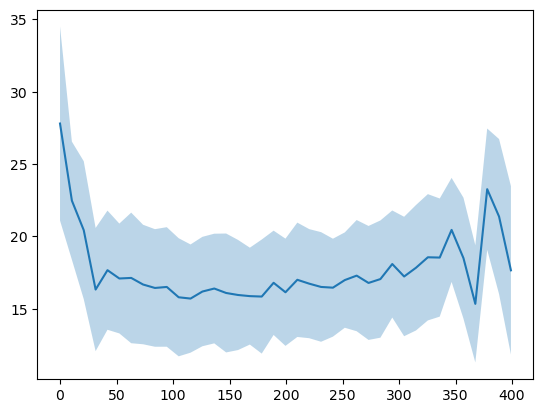

In [163]:
av = np.mean(profiles, axis=0)
std = np.std(profiles, axis=0)

plt.plot(bins_, av)
plt.fill_between(bins_, av+std, av-std,
                 alpha=.3)

In [213]:
wws = [300, 400, 500, 600, 800, 1000]

def shear_amplitude_order(uv_list, boundary=20):
    '''uv_list sotred by shear (v_y) amplitude on the edges'''
    shear_amplitude = [(uv[:,-boundary:,1].mean() - uv[:,:boundary,1].mean()) for uv in uv_list]
    return np.argsort(shear_amplitude)

for width in wws:
    tiff_list = analyze_image_widths(r"C:\Users\victo\Downloads\HT1080", width, dw=width//30, make_plot=False)#, ax=ax)
    uv_list = Parallel(n_jobs=5)(delayed(uv_time_average)(tiff_path) for tiff_path in tiff_list[:])
    # remove None
    uv_list1 = [uv for uv,ti in zip(uv_list, tiff_list) if uv is not None]
    tiff_list1 = [ti for uv,ti in zip(uv_list, tiff_list) if uv is not None]
    print(len(tiff_list1), " from ", len(tiff_list))

    idx = shear_amplitude_order(uv_list1) 


    for tiff_path in np.array(tiff_list1)[idx[::-1]][:3]:
        frame_num,_ , im_width  = imread(tiff_path).shape

        exp_num = os.path.basename(tiff_path)[:-4]#.spilt(".")
        save_path = r"C:\Users\victo\Downloads\HT1080\Odd_test/w"+str(width)+ "/" +exp_num+"/Mask2/"
        os.makedirs(save_path, exist_ok=True)

        for i,frame in enumerate(range(frame_num)):
            masks,_,_,_ = model.eval(imread(tiff_path)[frame], 
                                                diameter=32., channels = [1,3],
                                                flow_threshold=1,
                                                cellprob_threshold=-6
                                                )
            cv2.imwrite(save_path + str(i) + "_cp_masks.png", masks)
            # if i>3:
            #     break

35  from  43


100%|██████████| 101/101 [00:00<00:00, 2582.13it/s]


14  from  21


100%|██████████| 101/101 [00:00<00:00, 1378.64it/s]


20  from  31


...

100%|██████████| 101/101 [00:00<00:00, 1002.44it/s]


35  from  43


100%|██████████| 101/101 [00:00<00:00, 805.08it/s]


18  from  29


100%|██████████| 101/101 [00:00<00:00, 616.56it/s]


In [209]:
np.array(tiff_list1)[idx[::-1]][:3]

array(['C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s53_2.tif',
       'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s65_3.tif',
       'C:\\Users\\victo\\Downloads\\HT1080\\27072018_CROPPED\\s65_2.tif'],
      dtype='<U59')

In [210]:
save_path + str(i) + "_cp_masks.png"

'C:\\Users\\victo\\Downloads\\HT1080\\Odd_test/w300/s65_2/Mask2/4_cp_masks.png'

In [212]:
for tiff_path in np.array(tiff_list1)[idx[::-1]][1:3]:
    frame_num,_ , im_width  = imread(tiff_path).shape

    exp_num = os.path.basename(tiff_path)[:-4]#.spilt(".")
    save_path = r"C:\Users\victo\Downloads\HT1080\Odd_test/w"+str(width)+ "/" +exp_num+"/Mask2/"
    os.makedirs(save_path, exist_ok=True)

    for i,frame in enumerate(range(frame_num)):
        masks,_,_,_ = model.eval(imread(tiff_path)[frame], 
                                            diameter=32., channels = [1,3],
                                            flow_threshold=1,
                                            cellprob_threshold=-6
                                            )
        cv2.imwrite(save_path + str(i) + "_cp_masks.png", masks)
        if i>3:
            break

100%|██████████| 101/101 [00:00<00:00, 2634.07it/s]


Text(0.5, 1.0, 'Cell Centers on Original Image')

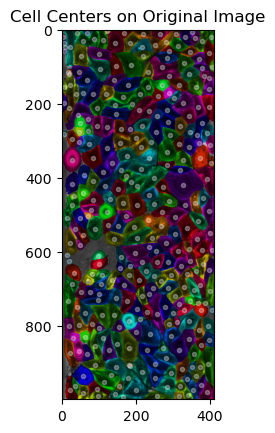

In [135]:
from skimage.measure import label, regionprops
# %matplotlib qt
# Calculate cell centers from the flow field

plt.figure()
overlay = plot.mask_overlay(img, masks, )
plt.imshow(overlay)


centers = np.array([region.centroid for region in regionprops(masks)])
# plt.imshow(img, cmap='gray')  # Display the original image
for center in centers:
    plt.plot(center[1], center[0], 'w.', alpha=.3)  # Plot centers in red
plt.title('Cell Centers on Original Image')

## Cell Divisions with Random Forest

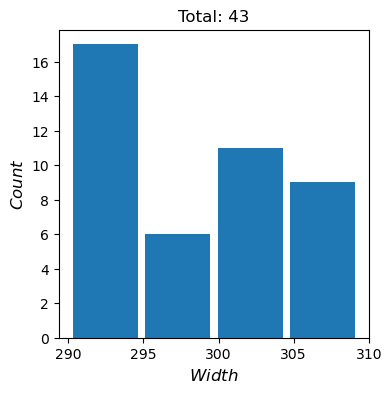

In [ ]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean
import os
import sys, time,random
from pathlib import Path
from PIL import Image
from joblib import Parallel, delayed
import h5py
import pickle 

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

width = 300
tiff_list = analyze_image_widths(r"C:\Users\victo\Downloads\HT1080", width, dw=width//30, make_plot=True)#, ax=ax)

In [2]:
'''Import model created in ..\stone_segmentation_WekaLike.py'''
from natsort import natsorted
from skimage import data, segmentation, feature, future

model_path = r"C:\Users\victo\Downloads\HT1080\Odd_test\Weka_divisions" + "\RandomForestClassifier_seg_divisions.pkl"

''' Load Model ''' 
with open(model_path, 'rb') as f:
    clf, features_func = pickle.load(f) 

In [4]:
'''Make Prediction on Test Image'''
%matplotlib qt
image_list = glob.glob(r"C:\Users\victo\Downloads\HT1080\Odd_test\s53\Raw\*.tif")

image_list = natsorted(image_list, key=lambda y: y.lower())
full_img = cv2.imread(image_list[-10])[:400,:]
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

features_new = features_func(full_img)
result_new = future.predict_segmenter(features_new, clf)

fig, axs = plt.subplots(3,1) 
img_clahe = clahe.apply(full_img[:,:,0])
axs[0].imshow(255-img_clahe, "gray")
# axs[0].imshow(full_img/full_img.max())
axs[0].set_axis_off()

axs[2].imshow(full_img/full_img.max())
axs[2].imshow(result_new, alpha=.6)
axs[2].set_axis_off()

axs[1].imshow(result_new, alpha=.9)
axs[1].set_axis_off()

In [ ]:
# tiff = Image.open(tiff_list1[0])
# tiff_frame_list = multiTiff_to_list(tiff)

# divisions_list = []
# for i,img in enumerate(tiff_frame_list):
#     features_new = features_func(cv2.cvtColor(img, cv2.COLOR_GRAY2RGB))
#     divisions_list.append(future.predict_segmenter(features_new, clf))

In [ ]:
def divisions(tiff_path, clf, skip=10):
    tiff = Image.open(tiff_path)
    tiff_frame_list = multiTiff_to_list(tiff)

    divisions_list = []
    for i,img in enumerate(tiff_frame_list[::skip]):
        features_new = features_func(cv2.cvtColor(img, cv2.COLOR_GRAY2RGB))
        divisions_list.append(future.predict_segmenter(features_new, clf))
    
    return divisions_list

divisions_lists = Parallel(n_jobs=5)(delayed(divisions)(tiff_path, clf, skip=10) for tiff_path in tiff_list1[-10:])

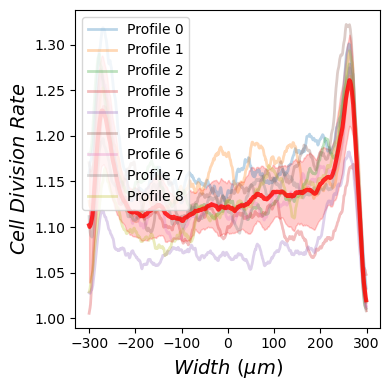

In [26]:
# %matplotlib qt
profiles = []
fig = plt.figure(figsize=(4,4))

# Find average stripe width
target_length = int(np.mean([d[0].shape[-1] for d in divisions_lists])*.74)

# Precompute width for the target length
width = np.linspace(-target_length // 2, target_length // 2, target_length)

for i,divisions_list in enumerate(divisions_lists):
    all_frames = np.sum(divisions_list, axis=0)/len(divisions_list)
    profile = np.mean(all_frames, axis=0)
    # print(len(profile))
    if np.mean(profile)<1.2:
        # Interpolate the profile to the target length using np.interp
        original_length = len(profile)
        x_original = np.linspace(0, 1, original_length)  # Original x values
        x_target = np.linspace(0, 1, target_length)  # Target x values
        
        # Interpolate the profile
        interpolated_profile = np.interp(x_target, x_original, profile)
        
        profiles.append(interpolated_profile)
        plt.plot(width, interpolated_profile, linewidth=2, alpha=0.3, label=f'Profile {i}')        

av_profile = np.mean(profiles, axis=0)
std_profile = np.std(profiles, axis=0)
plt.plot(width, av_profile,"r", linewidth=3, alpha=.8)
plt.fill_between(width, av_profile-std_profile, av_profile+std_profile,
                 color="r", alpha=.2)
plt.xlabel("$Width ~(\mu m)$", fontsize=14)
plt.ylabel("$Cell ~Division ~Rate$", fontsize=14)   
plt.tight_layout() 
plt.legend()
fig.savefig(r"C:\Users\victo\OneDrive - BGU\DATA\Odd_test\Images/"+ str(int(len(profile)*.74))+".svg")
# 

In [ ]:
def division_profiles(divisions_lists, output_path):
    """
    Analyzes and plots the average profiles from the given divisions lists.

    Parameters:
    - divisions_lists: list of lists, where each inner list contains arrays of division data.
    - output_path: str, the path where the output figure will be saved.
    """
    profiles = []
    fig = plt.figure(figsize=(4, 4))

    # Find average stripe width
    target_length = int(np.mean([d[0].shape[-1] for d in divisions_lists]) * .74)

    # Precompute width for the target length
    width = np.linspace(-target_length // 2, target_length // 2, target_length)

    for i, divisions_list in enumerate(divisions_lists):
        all_frames = np.sum(divisions_list, axis=0) / len(divisions_list)
        profile = np.mean(all_frames, axis=0)

        if np.mean(profile) < 1.3:
            # Interpolate the profile to the target length using np.interp
            original_length = len(profile)
            x_original = np.linspace(0, 1, original_length)  # Original x values
            x_target = np.linspace(0, 1, target_length)  # Target x values
            
            # Interpolate the profile
            interpolated_profile = np.interp(x_target, x_original, profile)
            
            profiles.append(interpolated_profile)
            plt.plot(width, interpolated_profile, linewidth=2, alpha=.3, label=f'Profile {i}')        

    # Calculate average and standard deviation of profiles
    av_profile = np.mean(profiles, axis=0)
    std_profile = np.std(profiles, axis=0)

    # Plot average profile and standard deviation
    plt.plot(width, av_profile, "r", linewidth=3, alpha=0.8)
    plt.fill_between(width, av_profile - std_profile, av_profile + std_profile,
                     color="r", alpha=0.2)
    plt.xlabel("$Width ~(\mu m)$", fontsize=14)
    plt.ylabel("$Cell ~Division ~Rate$", fontsize=14)   
    plt.tight_layout() 
    plt.legend()
    
    # Save the figure
    fig.savefig(output_path + "/"+ str(int(len(profile) * 0.74)) + ".svg")
    dict = {'width': width, 'division_av': av_profile, 'division_std': std_profile} 
    pd.DataFrame(dict).to_csv(output_path + "/"+ str(int(len(profile) * 0.74)) + "_sort.csv")
    return pd.DataFrame(dict)

# Example usage
ww = 400
tiff_list = analyze_image_widths(r"C:\Users\victo\Downloads\HT1080", ww, dw=ww//30, make_plot=True)
print(ww, ww//30)

uv_list = Parallel(n_jobs=5)(delayed(uv_time_average)(tiff_path) for tiff_path in tiff_list[:])
uv_list1 = [uv for uv,ti in zip(uv_list, tiff_list) if uv is not None]
tiff_list1 = [ti for uv,ti in zip(uv_list, tiff_list) if uv is not None]
print(len(tiff_list1), " from ", len(tiff_list))
divisions_lists = Parallel(n_jobs=5)(delayed(divisions)(tiff_path, clf) for tiff_path in tiff_list1[:])
division_profiles(divisions_lists, r"C:\Users\victo\OneDrive - BGU\DATA\Odd_test\Images")


In [ ]:
divisions_lists = Parallel(n_jobs=5)(delayed(divisions)(tiff_path, clf) for tiff_path in tiff_list1[:])
division_profiles(divisions_lists, r"C:\Users\victo\OneDrive - BGU\DATA\Odd_test\Images")

300 15
35  from  43
400 20
14  from  21
500 25
20  from  31
600 30
16  from  26
800 40
35  from  43
1000 50
18  from  29


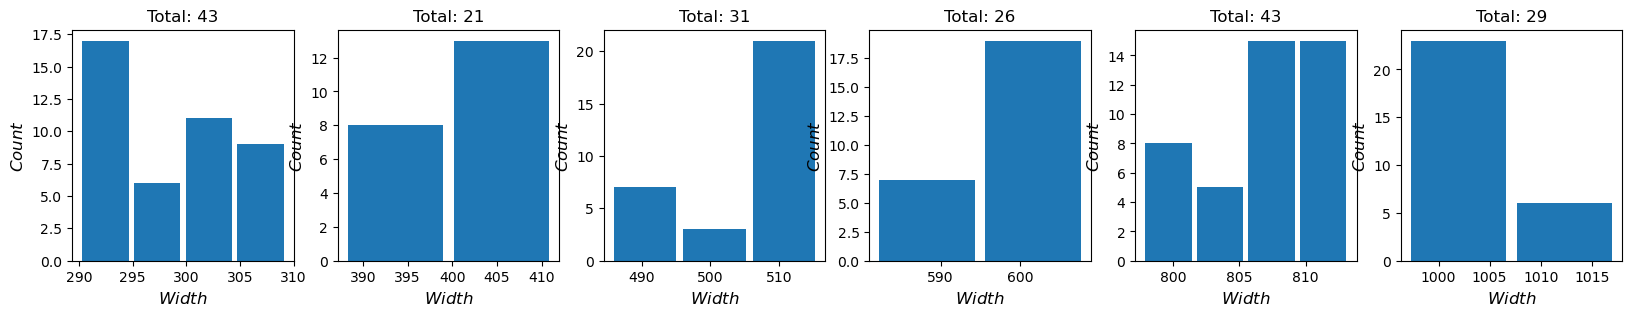

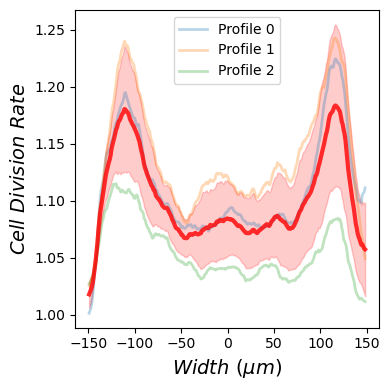

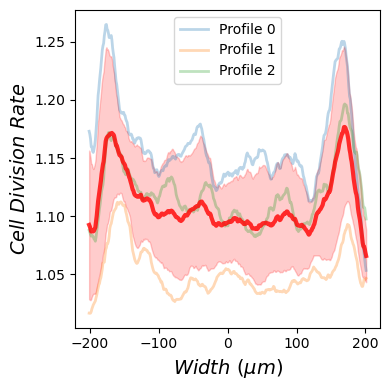

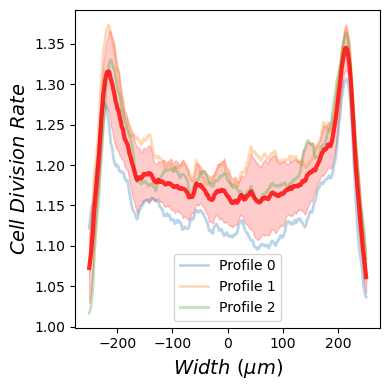

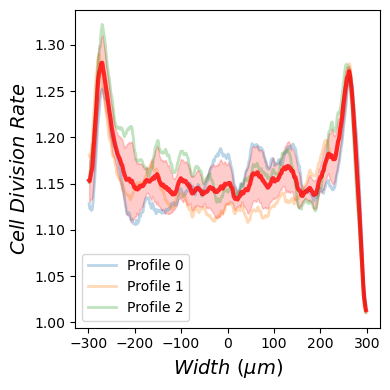

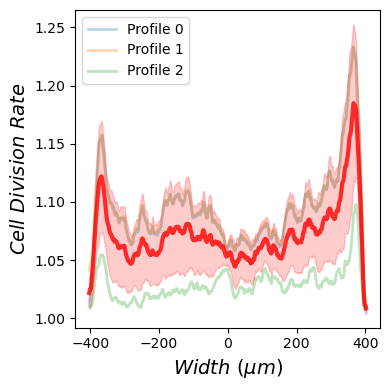

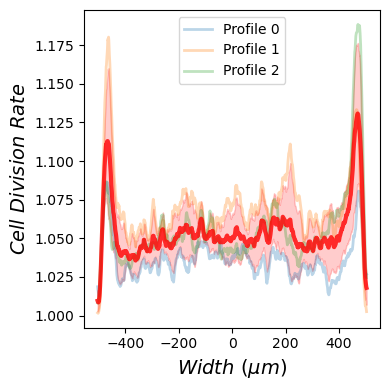

In [5]:
wws = [300, 400, 500, 600, 800, 1000,]# 1500]

def shear_amplitude_order(uv_list, boundary=20):
    '''uv_list sotred by shear (v_y) amplitude on the edges'''
    shear_amplitude = [(uv[:,-boundary:,1].mean() - uv[:,:boundary,1].mean()) for uv in uv_list]
    return np.argsort(shear_amplitude)

fig, axs = plt.subplots(1,len(wws), figsize=(20,3)) 
axs = axs.ravel()
for ax,ww in zip(axs,wws[:]):
    try:
        tiff_list = analyze_image_widths(r"C:\Users\victo\Downloads\HT1080", ww, dw=ww//30, make_plot=True, ax=ax)
        print(ww, ww//20)

        uv_list = Parallel(n_jobs=5)(delayed(uv_time_average)(tiff_path) for tiff_path in tiff_list[:])
        uv_list1 = [uv for uv,ti in zip(uv_list, tiff_list) if uv is not None]
        tiff_list1 = [ti for uv,ti in zip(uv_list, tiff_list) if uv is not None]
        print(len(tiff_list1), " from ", len(tiff_list))

        idx = shear_amplitude_order(uv_list1) 

        divisions_lists = Parallel(n_jobs=5)(delayed(divisions)(tiff_path, clf) for tiff_path in np.array(tiff_list1)[idx[::-1]][:3])
        division_profiles(divisions_lists, r"C:\Users\victo\OneDrive - BGU\DATA\Odd_test\Images")
    except:
        print("An exception occurred")


In [16]:
"sort" in div

True

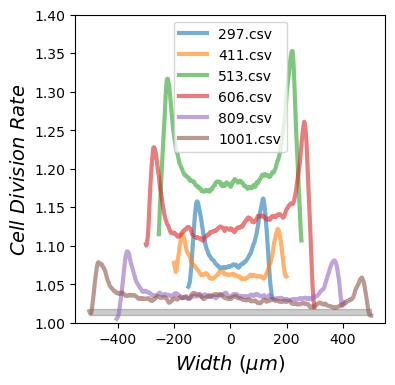

In [21]:
%matplotlib inline
divisions_list = glob.glob(r"C:\Users\victo\OneDrive - BGU\DATA\Odd_test\Images\*.csv")
divisions_list = natsorted(divisions_list, key=lambda y: y.lower())

fig, ax = plt.subplots(1,1, figsize=(4,4)) 
for div in divisions_list[:-1]:
    if "sort" not in div:
        df = pd.read_csv(div)
        ax.plot(df.width, df.division_av,  linewidth=3, alpha=0.6, label=os.path.basename(div))
        # ax.fill_between(df.width, 
        #                 df.division_av - df.division_std, 
        #                 df.division_av + df.division_std,
        #                 color="r", alpha=0.2)
    
df = pd.read_csv(divisions_list[-1])
ax.fill_between([-500,500], 
                df.division_av.mean() + df.division_av.std(), 
                df.division_av.mean() - df.division_av.std(),
                color="k", alpha=0.2)

ax.set_xlabel("$Width ~(\mu m)$", fontsize=14)
ax.set_ylabel("$Cell ~Division ~Rate$", fontsize=14)
ax.set_ylim([1.,1.4])
plt.legend()

# TrackPy Examples

In [5]:
import numpy as np
import pandas as pd
from pandas import DataFrame, Series  # for convenience
import matplotlib.pyplot as plt
import glob
import pims
import trackpy as tp
import imageio
from skimage.measure import label, regionprops
from natsort import natsorted

def gray(image):
    # Assuming the image is already in grayscale format
    return image  # No need to take a channel, as it's already grayscale

# Load 16-bit grayscale images from the specified directory
def load_grayscale_images(path,start=0,finish=-1):
    images = []
    image_list = glob.glob(path)
    image_list = natsorted(image_list, key=lambda y: y.lower())
    for filename in image_list[start:finish]:
        img = imageio.imread(filename)  # Read the image
        if img.dtype == np.uint16:  # Check if the image is 16-bit
            images.append(gray(img))  # Append the grayscale image
        else:
            print(f"Image {filename} is not 16-bit grayscale.")
    return images

# Use the function to load images
frames = load_grayscale_images(r'C:\Users\victo\Downloads\SB_lab\HBEC\s2(120-919)\Raw\Mask001\*.png',
                               start=300,finish=310)

In [6]:
# Initialize an empty list to store DataFrames
features_list = []

for num, img in enumerate(frames):
    centers = np.array([region.centroid for region in regionprops(img)])
    # Create a DataFrame for the current frame's centers
    frame_features = pd.DataFrame({
        'x': centers[:, 1],  # x-coordinates
        'y': centers[:, 0],  # y-coordinates
        'frame': num,        # frame number
    })
    # Append the DataFrame to the list
    features_list.append(frame_features)

# Concatenate all DataFrames in the list into a single DataFrame
features = pd.concat(features_list, ignore_index=True)


In [8]:
%matplotlib qt
tp.annotate(features[features.frame==0], frames[0], plot_style={'markersize':5, 'alpha':.3})

<AxesSubplot: >

In [16]:
# tp.link_df: creates trajectories
search_range = 15
t = tp.link_df(features, search_range, memory=1)
# plt.imshow(img)
# tp.plot_traj(t)

Frame 9: 5600 trajectories present.


In [12]:
plt.imshow(img)
tp.plot_traj(tp.filter_stubs(t, 5))

<AxesSubplot: xlabel='x [px]', ylabel='y [px]'>

In [7]:
t1 = tp.filter_stubs(t, 50)

In [10]:
t1 = tp.filter_stubs(t, 50)
# Compare the number of particles in the unfiltered and filtered data.
print('Before:', t['particle'].nunique())
print('After:', t1['particle'].nunique())

Before: 62004
After: 8571


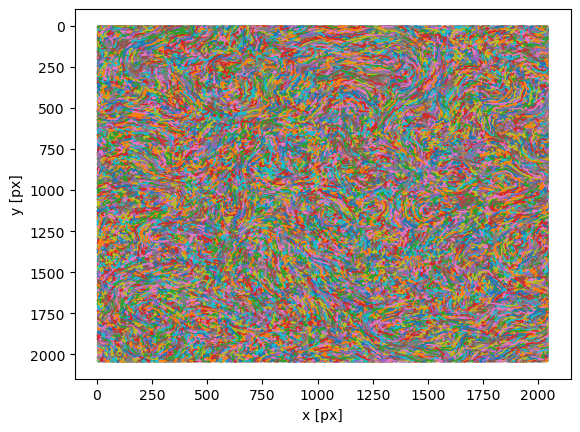

<AxesSubplot: xlabel='x [px]', ylabel='y [px]'>

In [7]:
tp.plot_traj(t)

Text(0, 0.5, 'Frequency')

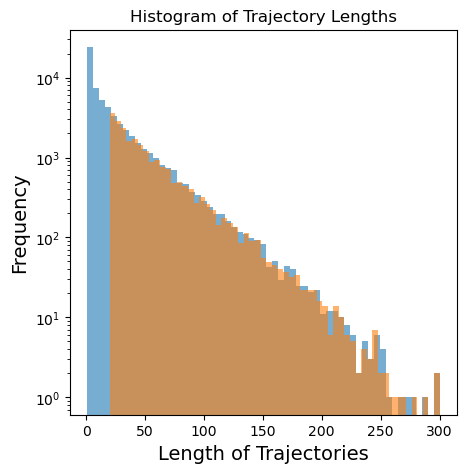

In [9]:
%matplotlib inline
# Assuming 'trajectory_id' is the column that identifies each trajectory
plt.figure(figsize=(5, 5))
bin_num = 60

for tt in [t, tp.filter_stubs(t, 20)]:
    trajectory_lengths = tt.groupby('particle').size().reset_index(name='length')

    plt.hist(trajectory_lengths['length'], 
            bins=np.linspace(trajectory_lengths['length'].min(),
                            trajectory_lengths['length'].max(), 
                            bin_num), 
                            alpha=0.6)#density=True, color='blue',
plt.yscale('log')
plt.title('Histogram of Trajectory Lengths')
plt.xlabel('Length of Trajectories', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

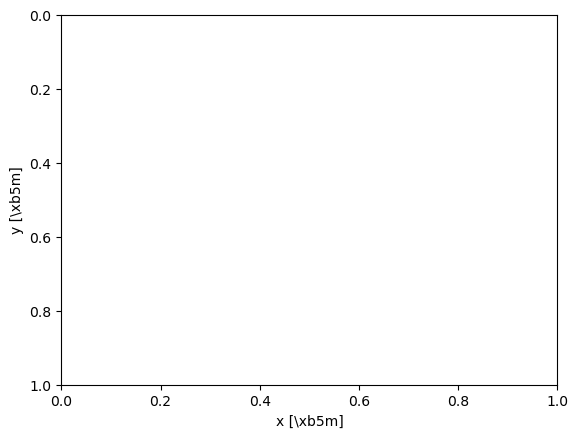

<AxesSubplot: xlabel='x [\\xb5m]', ylabel='y [\\xb5m]'>

In [10]:
%matplotlib inline
tp.plot_traj(tp.filter_stubs(t, 50), 100/285., 24)

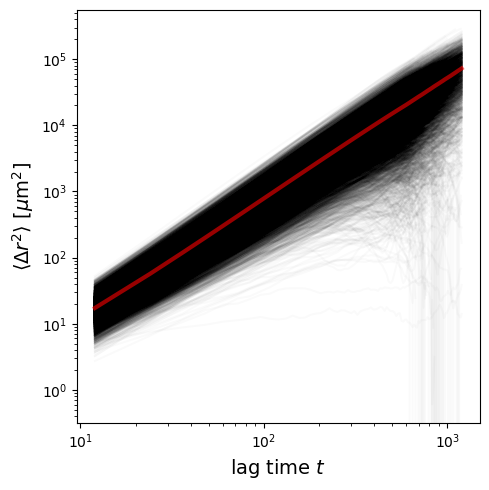

In [11]:
tm = tp.filter_stubs(t, 50)
im = tp.imsd(tm, 0.74, 1/12)  # microns per pixel = 100/285., frames per hour = 24

em = tp.emsd(tm, 0.74, 1/12)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(im.index, im, 'k-', alpha=0.02)  # black lines, semitransparent
ax.plot(em.index, em, 'r', linewidth=3, alpha=0.6)
ax.set_ylabel(r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]', fontsize=14)
ax.set_xlabel('lag time $t$', fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()

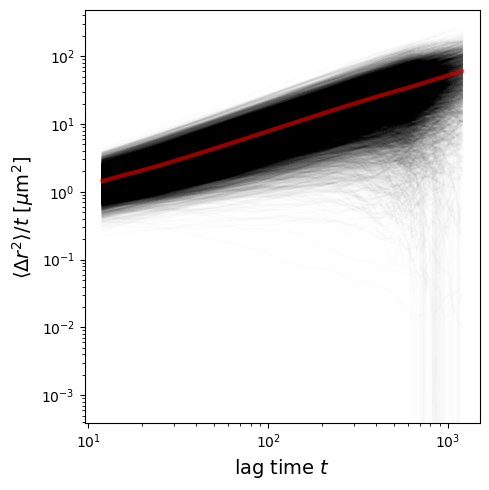

In [140]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(im.index, im.div(im.index, axis=0), 'k-', alpha=0.01)  # black lines, semitransparent
ax.plot(em.index, em/em.index, 'r', linewidth=3, alpha=0.6)
ax.set_ylabel(r'$\langle \Delta r^2 \rangle /t$ [$\mu$m$^2$] ', fontsize=14)
ax.set_xlabel('lag time $t$', fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()